# Практика: логистическая регрессия с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите бинарный датасет;
2. подготовите данные для обучения;
3. реализуете ключевые части логистической регрессии **с нуля**:
   - сигмоиду,
   - log-loss,
   - градиентный спуск,
   - предсказание вероятностей и классов;
4. обучите свою модель;
5. сравните её качество и коэффициенты с реализацией из `scikit-learn`;
6. поэкспериментируете с порогом классификации.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Breast Cancer Wisconsin` из `sklearn.datasets`:
- задача **бинарной классификации**;
- признаки числовые;
- датасет удобен для изучения логистической регрессии без сложной предобработки категориальных переменных.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - где ваша реализация может уступать библиотечной;
   - как влияет изменение порога классификации.

## Коротко о теории

### 1. Логистическая регрессия
Логистическая регрессия моделирует вероятность положительного класса:

\[
P(y=1 \mid x) = \sigma(z), \quad z = w^T x + b
\]

где \(\sigma(z)\) — сигмоида:

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

### 2. Почему не линейная регрессия
Если предсказывать класс линейной моделью напрямую, прогноз может выйти за диапазон \([0, 1]\).  
Сигмоида решает эту проблему: она переводит любое число в вероятность.

### 3. Функция потерь
Для логистической регрессии используется **log-loss**:

\[
L = - \frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)
\right]
\]

### 4. Обучение
Мы будем минимизировать log-loss методом **градиентного спуска**.

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.linear_model.LogisticRegression`:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

### 6. Почему нужна стандартизация
Градиентный спуск работает стабильнее, когда признаки находятся примерно в одном масштабе.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер X:", X.shape)
print("Размер y:", y.shape)
display(X.head())
display(y.value_counts().rename(index={0: "malignant", 1: "benign"}))

Размер X: (569, 30)
Размер y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


target
benign       357
malignant    212
Name: count, dtype: int64

Пропуски по признакам:


mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64


Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


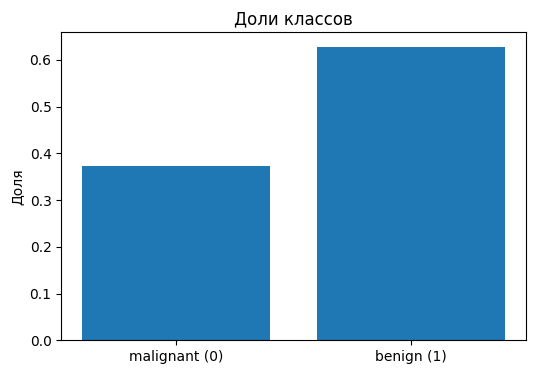

In [3]:
print("Пропуски по признакам:")
display(X.isna().sum().sort_values(ascending=False).head())

print("\nБазовая статистика:")
display(X.describe().T.head(10))

class_share = y.value_counts(normalize=True).sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["malignant (0)", "benign (1)"], class_share.values)
plt.title("Доли классов")
plt.ylabel("Доля")
plt.show()

## Шаг 1. Разделение данных и стандартизация

Ниже нужно:
1. разбить выборку на train и test;
2. стандартизовать признаки только по train-части;
3. получить `X_train_scaled` и `X_test_scaled`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`;
- `StandardScaler().fit(...)` делаем **только на train**.

In [5]:
# YOUR CODE HERE
# 1) Разбейте данные на train/test
# 2) Создайте scaler
# 3) Обучите scaler на train
# 4) Преобразуйте X_train и X_test

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y) # stratify позволяет разделить так чтобы доля классов (больной/здоровый) в 
                                                                                                    # train test была одинаковой
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (455, 30)
Test shape: (114, 30)


## Шаг 2. Реализуем сигмоиду

Допишите функцию `sigmoid(z)`.

Проверка:
- `sigmoid(0)` должно быть равно `0.5`;
- функция должна работать и со скалярами, и с `numpy`-массивами.

In [6]:
def sigmoid(z):
    # YOUR CODE HERE
    return 1/(1 + np.exp(-z))


print("sigmoid(0) =", sigmoid(0))
print("sigmoid([-1, 0, 1]) =", sigmoid(np.array([-1.0, 0.0, 1.0])))

sigmoid(0) = 0.5
sigmoid([-1, 0, 1]) = [0.26894142 0.5        0.73105858]


## Шаг 3. Реализуем log-loss

Напишите функцию `compute_log_loss(y_true, y_pred_proba)`.

Важно:
- чтобы избежать `log(0)`, используйте `np.clip(y_pred_proba, 1e-15, 1 - 1e-15)`.

In [7]:
def compute_log_loss(y_true, y_pred_proba):
    # YOUR CODE HERE
    y_pred_proba = np.clip(y_pred_proba, 1e-15, 1-1e-15)# делаем y_pred_proba в диапозоне от 1e-15 до 1-1e-15, так как слишком большие или слишком маленькие значения могут 
                                                        # сломать вычисления
    loss = -np.mean(y_true * np.log(y_pred_proba) + (1 - y_true)*np.log(1 - y_pred_proba))
    return loss

toy_y = np.array([0, 1, 1, 0])
toy_p = np.array([0.1, 0.9, 0.8, 0.3])
print("Toy log-loss:", compute_log_loss(toy_y, toy_p))

Toy log-loss: 0.19763488164214868


## Шаг 4. Один шаг градиентного спуска

Напомним:
- \(z = Xw + b\)
- \(\hat{p} = \sigma(z)\)

Градиенты для log-loss:
\[
dw = 
rac{1}{n} X^T(\hat{p} - y), \qquad db = 
rac{1}{n}\sum(\hat{p} - y)
\]

Ниже нужно реализовать функцию, которая считает:
- вероятности,
- loss,
- градиенты `dw`, `db`.

In [8]:
def forward_backward(X, y, w, b):
    # YOUR CODE HERE
    m = X.shape[0]
    # 1) посчитать z
    z = X @ w + b
    # 2) посчитать p = sigmoid(z)
    p = sigmoid(z)
    # 3) посчитать loss
    loss = compute_log_loss(y, p)
    # 4) посчитать dw и db
    dw = (1/m) * (X.T @ (p - y))
    db = (1/m) * (np.sum(p - y))
    return p, loss, dw, db

n_features = X_train_scaled.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

p0, loss0, dw0, db0 = forward_backward(X_train_scaled, y_train.values, w0, b0)
print("Initial loss:", loss0)
print("dw shape:", dw0.shape)
print("db:", db0)

Initial loss: 0.6931471805599453
dw shape: (30,)
db: -0.12637362637362637


## Шаг 5. Собираем модель в класс

Допишите методы:
- `fit`
- `predict_proba`
- `predict`

Требования:
- обучение через градиентный спуск;
- сохранять историю значения loss;
- в `predict` использовать порог `threshold`.

In [17]:
class MyLogisticRegressionGD:
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        # YOUR CODE HERE
        # 1) инициализируйте w и b
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.loss_history = []
        # 2) в цикле вызовите forward_backward
        for i in range(self.n_iters) :
            p, loss, dw, db = forward_backward(X, y, self.w, self.b)
        # 3) обновите параметры
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
        # 4) сохраните loss в self.loss_history
            self.loss_history.append(loss)
        
        return self

    def predict_proba(self, X):
        # YOUR CODE HERE
        z = X @ self.w + self.b
        proba = sigmoid(z)
        return proba

    def predict(self, X):
        # YOUR CODE HERE
        proba = self.predict_proba(X)
        preds = (proba >= self.threshold).astype(int)
        return preds

## Шаг 6. Обучаем свою модель

Попробуйте обучить свою модель и посмотрите:
- уменьшается ли `loss`;
- какое качество получается на test.

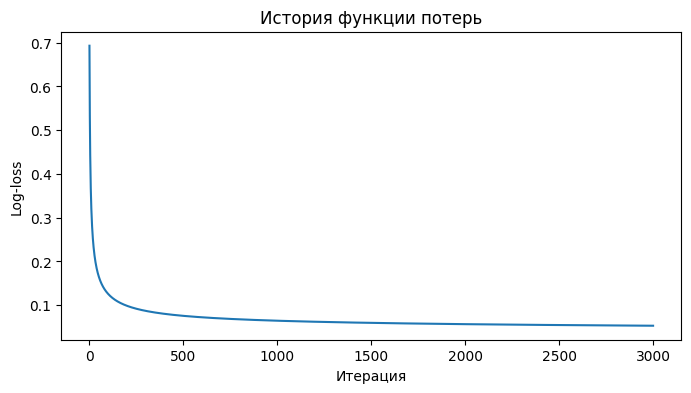

In [18]:
my_model = MyLogisticRegressionGD(
    learning_rate=0.05,   # подберите разумное значение
    n_iters=3000,         # задайте число итераций
    threshold=0.5
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled, y_train)

plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()

## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

Подсказка:
- для ROC-AUC нужны **вероятности**, а не классы.

In [19]:
# YOUR CODE HERE
my_proba_test = my_model.predict_proba(X_test_scaled)
my_pred_test = my_model.predict(X_test_scaled)

my_metrics = {
    "accuracy": accuracy_score(y_test, my_pred_test),
    "precision": precision_score(y_test, my_pred_test),
    "recall": recall_score(y_test, my_pred_test),
    "f1": f1_score(y_test, my_pred_test),
    "roc_auc": roc_auc_score(y_test, my_proba_test),
}

pd.Series(my_metrics).round(4)

accuracy     0.9649
precision    0.9857
recall       0.9583
f1           0.9718
roc_auc      0.9960
dtype: float64

## Шаг 8. Confusion matrix и ROC-кривая

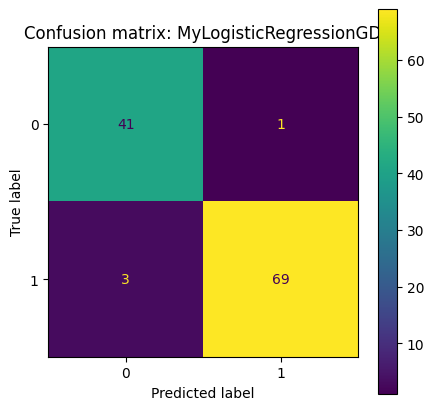

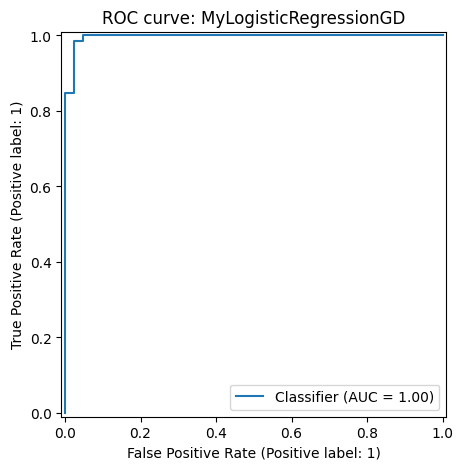

              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [20]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, my_pred_test, ax=ax)
plt.title("Confusion matrix: MyLogisticRegressionGD")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, my_proba_test, ax=ax)
plt.title("ROC curve: MyLogisticRegressionGD")
plt.show()

print(classification_report(y_test, my_pred_test))

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечную модель и сравните её с вашей реализацией.

Рекомендации:
- используйте `LogisticRegression(max_iter=1000)`;
- обучайте на тех же стандартизованных данных.

In [26]:
sk_model = LogisticRegression(max_iter=1000, solver="lbfgs", C=1e5)

# YOUR CODE HERE
# 1) обучите sk_model
sk_model.fit(X_train_scaled, y_train)
# 2) получите вероятности и классы на test
pred = sk_model.predict(X_test_scaled)
proba = sk_model.predict_proba(X_test_scaled)[:,1]
# 3) посчитайте те же метрики

sk_metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1": f1_score(y_test, pred),
    "roc_auc": roc_auc_score(y_test, proba),
}

pd.Series(sk_metrics).round(4)

accuracy     0.9211
precision    0.9701
recall       0.9028
f1           0.9353
roc_auc      0.9712
dtype: float64

## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Подумайте:
- почему результаты могут быть немного разными;
- что в библиотечной реализации сделано устойчивее.

In [27]:
comparison = pd.DataFrame([my_metrics, sk_metrics], index=["my_model", "sklearn"])
display(comparison.round(4))

coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "my_coef": my_model.w,
    "sklearn_coef": sk_model.coef_.ravel(),
})
coef_comparison["abs_diff"] = np.abs(coef_comparison["my_coef"] - coef_comparison["sklearn_coef"])
display(coef_comparison.sort_values("abs_diff", ascending=False).head(10))

,accuracy,precision,recall,f1,roc_auc
my_model,0.9649,0.9857,0.9583,0.9718,0.9960
sklearn,0.9211,0.9701,0.9028,0.9353,0.9712


,feature,my_coef,sklearn_coef,abs_diff
5,mean compactness,0.265638,227.679761,227.414122
26,worst concavity,-0.696837,-164.768756,164.071919
16,concavity error,0.144131,146.252651,146.108520
13,area error,-0.808264,-128.869155,128.060891
10,radius error,-0.935962,-106.755668,105.819706
17,concave points error,-0.316322,-104.117817,103.801494
23,worst area,-0.917233,-104.676017,103.758784
12,perimeter error,-0.627814,81.403781,82.031595
15,compactness error,0.657070,-69.085636,69.742706
9,mean fractal dimension,0.401506,-68.711626,69.113132


## Шаг 11. Эксперимент с порогом классификации

По умолчанию обычно берут порог `0.5`, но это не всегда лучший выбор.

Ниже нужно сравнить метрики при порогах:
- 0.3
- 0.5
- 0.7

Подсказка:
- `pred = (proba >= threshold).astype(int)`

In [28]:
thresholds = [0.3, 0.5, 0.7]
rows = []

for threshold in thresholds:
    # YOUR CODE HERE
    pred_thr = (my_proba_test >= threshold).astype(int)
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred_thr),
        "precision": precision_score(y_test, pred_thr),
        "recall": recall_score(y_test, pred_thr),
        "f1": f1_score(y_test, pred_thr),
    })

pd.DataFrame(rows).round(4)

,threshold,accuracy,precision,recall,f1
0,0.3,0.9825,0.9730,1.0000,0.9863
1,0.5,0.9649,0.9857,0.9583,0.9718
2,0.7,0.9474,0.9853,0.9306,0.9571


## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

1. Почему для логистической регрессии используется сигмоида?
2. Почему в этой задаче мы считаем **log-loss**, а не MSE?
3. Зачем стандартизировать признаки перед обучением градиентным спуском?
4. Насколько близки метрики вашей реализации к `scikit-learn`?
5. Почему библиотечная модель обычно работает стабильнее и быстрее?
6. Как изменение порога влияет на precision и recall?
7. В каких задачах логистическая регрессия особенно хороша, а где может уступать более сложным моделям?

### Мои ответы
1. Сигмоида позволяет определить веротность отношения объекта к одному из двух классов
2. У MSE функция потерь будет несколько минимумов, у log-loss один глобальный минимум, поэтому в log-loss градиентный спуск сможет найти минимум наверняка, в отличии от MSE
3. Функция потерь будет очень вытянутая, поэтому градиентный спуск будет очень медленным. Стандартизация делает функцию более "круглой" и градиентный спуск работатет быстрее
4. threshold	accuracy	precision	recall	f1
0	0.3	0.9825	0.9730	1.0000	0.9863
1	0.5	0.9649	0.9857	0.9583	0.9718
2	0.7	0.9474	0.9853	0.9306	0.9571
разница вызвана наличием регуляризации в sklearn
5. В них заложены более сложные и точные математичские алгоритмы, а регуляризация по умолчанию позволяет избежать переобучения
6. Снижение порога увеличивает Recall (ловит больше положительных случаев), но уменьшает Precision (растёт число ложных срабатываний). Повышение порога увеличивает Precision (меньше ложных срабатываний), но уменьшает Recall (пропускаем больше реальных положительных случаев).
7. Работает хорошо когда нужна понятно, какой признак как влияет, когда данных немного, когда зависимость между признаками и целевой переменной примерно линейная.
Уступает другим моделям когда связи сложные и нелинейные, когда признаков очень много и они сильно взаимодействуют друг с другом.

## Дополнительные задания

### Задание A
Добавьте L2-регуляризацию в свою реализацию.

### Задание B
Постройте таблицу с 10 признаками, которые дают наибольший по модулю вклад в модель.

### Задание C
Попробуйте:
- уменьшить число итераций;
- изменить `learning_rate`;
- посмотреть, как это влияет на сходимость и метрики.

### Задание A
Реализую новый класс(наследуемый от написанного ранее) L2-регуляризацией

In [29]:
class MyLogisticRegressionGD_L2(MyLogisticRegressionGD):
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5, l2_lambda=0.01):
        super().__init__(learning_rate, n_iters, threshold)
        self.l2_lambda = l2_lambda # Сила регуляризации

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.loss_history = []

        for i in range(self.n_iters):
            # Используем forward_backward из родительского класса
            z = X @ self.w + self.b
            p = sigmoid(z)
            
            
            loss = compute_log_loss(y, p)
            self.loss_history.append(loss)
            
            dw = (1 / n_samples) * X.T @ (p - y)
            db = (1 / n_samples) * np.sum(p - y) 
            
            # ДОБАВЛЯЕМ L2 ШТРАФ К ГРАДИЕНТУ ВЕСОВ
            # dw_new = dw_old + lambda * w
            dw += self.l2_lambda * self.w
            
            # Обновляем параметры
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            
        return self

my_model_l2 = MyLogisticRegressionGD_L2(
    learning_rate=0.05, 
    n_iters=3000, 
    l2_lambda=0.1 
)

my_model_l2.fit(X_train_scaled, y_train.values)

pred_l2 = my_model_l2.predict(X_test_scaled)
proba_l2 = my_model_l2.predict_proba(X_test_scaled)

print("Accuracy с L2:", accuracy_score(y_test, pred_l2))
print("ROC-AUC с L2:", roc_auc_score(y_test, proba_l2))

print("\nСравнение весов:")
for i in range(5):
    print(f"Feat {i}: No Reg={my_model.w[i]:.4f}, L2 Reg={my_model_l2.w[i]:.4f}")

Accuracy с L2: 0.956140350877193
ROC-AUC с L2: 0.9957010582010581

Сравнение весов:
Feat 0: No Reg=-0.6267, L2 Reg=-0.2733
Feat 1: No Reg=-0.7657, L2 Reg=-0.2594
Feat 2: No Reg=-0.5962, L2 Reg=-0.2682
Feat 3: No Reg=-0.6500, L2 Reg=-0.2533
Feat 4: No Reg=-0.3023, L2 Reg=-0.1308


Из сравнения видно, что регуляризация "сжимает" веса упрощая модель

### Задание B
Выделяем важнейшие характеристики


Топ-10 самых важных признаков:


,feature,weight
21,worst texture,-1.1158
20,worst radius,-0.9424
27,worst concave points,-0.9388
10,radius error,-0.9360
23,worst area,-0.9172
28,worst symmetry,-0.8631
24,worst smoothness,-0.8366
22,worst perimeter,-0.8362
13,area error,-0.8083
1,mean texture,-0.7657


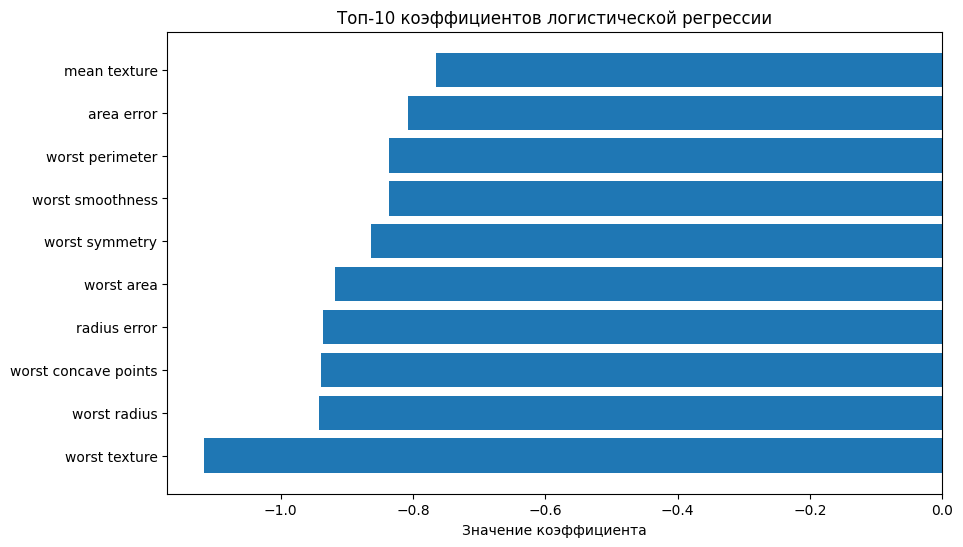

In [30]:
weights_df = pd.DataFrame({
    'feature': X.columns,
    'weight': my_model.w, # Использую веса основной модели без регуляризации
    'abs_weight': np.abs(my_model.w)
})

# Сортирую по абсолютному значению веса по убыванию
top_10 = weights_df.sort_values('abs_weight', ascending=False).head(10)

print("Топ-10 самых важных признаков:")
display(top_10[['feature', 'weight']].round(4))

plt.figure(figsize=(10, 6))
plt.barh(top_10['feature'], top_10['weight'])
plt.title('Топ-10 коэффициентов логистической регрессии')
plt.xlabel('Значение коэффициента')
plt.show()

### Задание С
Изменяю learning_rate и n_iters

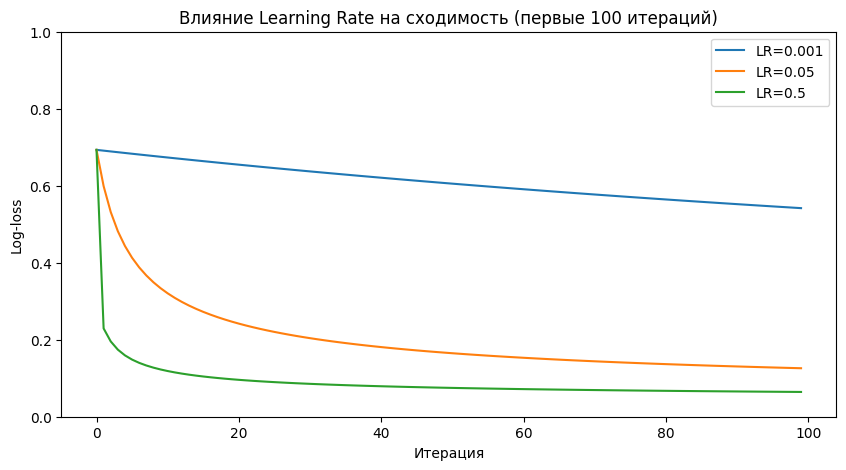

In [31]:
lr_list = [0.001, 0.05, 0.5]
plt.figure(figsize=(10, 5))

for lr in lr_list:
    model_exp = MyLogisticRegressionGD(learning_rate=lr, n_iters=100)
    model_exp.fit(X_train_scaled, y_train.values)
    plt.plot(model_exp.loss_history, label=f'LR={lr}')

plt.title('Влияние Learning Rate на сходимость (первые 100 итераций)')
plt.xlabel('Итерация')
plt.ylabel('Log-loss')
plt.legend()
plt.ylim(0, 1)
plt.show()

## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- загрузка данных;
- train/test split;
- стандартизация;
- реализация логистической регрессии с нуля;
- обучение;
- метрики качества;
- сравнение со `scikit-learn`;
- анализ порога классификации;
- выводы.

Не сдавайте ноутбук без текстовых выводов.

### Выводы
1. Разница в метриках у моей модели и модели sklearn вызвана наличием в последней регуляризации и более сложных мат. алгоритмов
2. Моя модель существенно зависит от learning_rate, который надо подбирать вручую, а модель из sklearn делает это автоматически
3. Снижение порога увеличивает recall и снижает precision, а увеличение порга наоборот